# Module 4 Lab 3: Textbook Problem 3.2

### Truck List Price vs. Best Price

**Name:** Mac Mckay

**Course:** CS 82A

**Repo:** https://github.com/raulmckay-blip/cs82a-portfolio

## Overview

This lab uses `truck.csv`, which has 23 trucks with their list price (`X`) and best sale price (`Y`), both in thousands of dollars. The goal is to see how closely the two prices line up, plot them, and use that to predict a sale price for a truck.

## Load the data

I renamed `X` and `Y` to `list_price` and `best_price` so it's easier to tell them apart.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

trucks = pd.read_csv('truck.csv')
trucks = trucks.rename(columns={'X': 'list_price', 'Y': 'best_price'})
print(trucks.shape)   # expect (23, 2)
trucks.head()

(23, 2)


,list_price,best_price
0,12.4,11.2
1,14.3,12.5
2,14.5,12.7
3,14.9,13.1
4,16.1,14.1


In [2]:
trucks.describe().round(2)

,list_price,best_price
count,23.00,23.00
mean,17.47,15.30
std,2.41,2.06
min,12.40,11.20
25%,15.80,14.05
50%,17.30,15.10
75%,19.30,16.85
max,22.40,19.60


## Pearson's r

In [3]:
r = trucks['list_price'].corr(trucks['best_price'])   # .corr() is Pearson by default
print(f'Pearson r = {r:.4f}')

Pearson r = 0.9985


Note: r comes out to 0.9985, which is almost a perfect positive relationship. When the list price goes up, the best price goes up by close to the same amount every time.

## Scatter plot

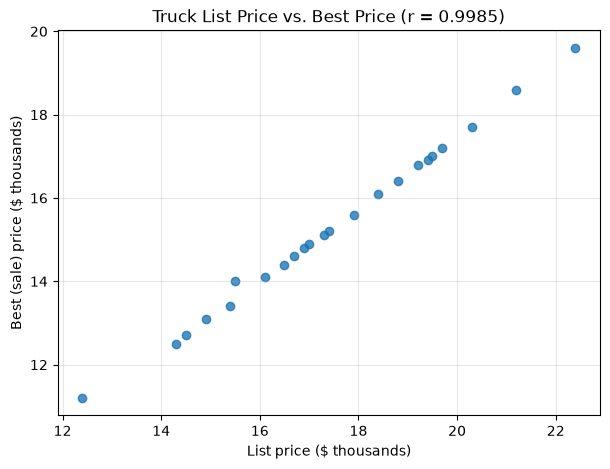

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(trucks['list_price'], trucks['best_price'], alpha=0.8)
plt.title(f'Truck List Price vs. Best Price (r = {r:.4f})')
plt.xlabel('List price ($ thousands)')
plt.ylabel('Best (sale) price ($ thousands)')
plt.grid(alpha=0.3)
plt.show()

Note: The points are almost exactly on a straight line, which is what you'd expect with an r that close to 1.

## Prediction

I picked a list price of $18,000 because it's right in the middle of the data. 

To get an actual number I fit a straight line through the points with `np.polyfit`. 

In [5]:
slope, intercept = np.polyfit(trucks['list_price'], trucks['best_price'], 1)
print(f'best_price ≈ {slope:.4f} * list_price + {intercept:.4f}')

my_list_price = 18
prediction = slope * my_list_price + intercept
print(f'List price ${my_list_price}k  ->  predicted best price ≈ ${prediction:.2f}k  (about ${prediction*1000:,.0f})')

best_price ≈ 0.8511 * list_price + 0.4346
List price $18k  ->  predicted best price ≈ $15.76k  (about $15,755)


Typical miss (std of residuals): $111
Biggest miss:                    $373
Data range for list price:       $12.4k to $22.4k


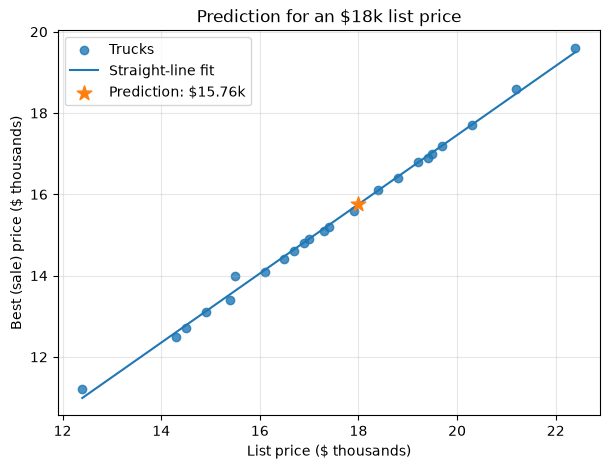

In [6]:
# how far off is the line for the trucks in the data?
residuals = trucks['best_price'] - (slope * trucks['list_price'] + intercept)
print(f'Typical miss (std of residuals): ${residuals.std()*1000:,.0f}')
print(f'Biggest miss:                    ${residuals.abs().max()*1000:,.0f}')
print(f'Data range for list price:       ${trucks.list_price.min():.1f}k to ${trucks.list_price.max():.1f}k')

# plot the line with my prediction on it
plt.figure(figsize=(7, 5))
plt.scatter(trucks['list_price'], trucks['best_price'], alpha=0.8, label='Trucks')
xs = np.linspace(trucks.list_price.min(), trucks.list_price.max(), 100)
plt.plot(xs, slope * xs + intercept, label='Straight-line fit')
plt.scatter([my_list_price], [prediction], s=120, marker='*', zorder=3, label=f'Prediction: ${prediction:.2f}k')
plt.title('Prediction for an $18k list price')
plt.xlabel('List price ($ thousands)')
plt.ylabel('Best (sale) price ($ thousands)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Note: For a truck with a list price of $18,000, the predicted best price is about **$15,755**, so roughly 12.5% off the list price.

## How confident am I?

I'm pretty confident in this prediction because r is so close to 1, meaning the trucks sit almost perfectly on a straight line. On top of that, $18k falls right in the middle of the data, and the line is usually only off by about $110. That said, all the trucks in this dataset are priced between $12.4k and $22.4k, so for anything above that range my confidence would drop a lot, since there's no data to show the pattern keeps going.

## AI Use

I used AI to help with syntax and refine wording on this lab.

The one part where it did more than that is the prediction section. Fitting a straight line with `np.polyfit` and checking how far off the line is (the residuals) is a bit past my curent knowledge. So I had AI write that code, then I went through it to understand what each line does.

